In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

print("Downloading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_all = mnist.data.astype('float32')
Y_all = mnist.target.astype('int')

# 1. First Split: Separate 10,000 samples for the final TEST set
X_train_val_orig, X_test_orig, Y_train_val_orig, Y_test_orig = train_test_split(
    X_all, 
    Y_all, 
    test_size=10000,       
    stratify=Y_all,        
    random_state=42        
)

# 2. Second Split: Separate the remaining 60,000 into 50,000 TRAIN and 10,000 VALIDATION
X_train_orig, X_val_orig, Y_train_orig, Y_val_orig = train_test_split(
    X_train_val_orig, 
    Y_train_val_orig, 
    test_size=10000,       # 10,000 samples for validation
    stratify=Y_train_val_orig,  
    random_state=42        
)

# 3. Normalize and Transpose (.T) all three sets to match shape (784, m)
X = X_train_orig.T / 255.0
Y = Y_train_orig

X_val = X_val_orig.T / 255.0
Y_val = Y_val_orig

X_test = X_test_orig.T / 255.0
Y_test = Y_test_orig

# 4. Verify the shapes
print("\n--- Shape Verification ---")
print("Train Features (X):   ", X.shape)      # Expected: (784, 50000)
print("Validation Features (X_val):", X_val.shape)  # Expected: (784, 10000)
print("Test Features (X_test):", X_test.shape)  # Expected: (784, 10000)


--- Shape Verification ---
Train Features (X):    (784, 50000)
Validation Features (X_val): (784, 10000)
Test Features (X_test): (784, 10000)


In [18]:


def initParams(hidden_layers):
    W = []
    b = []
    
    all_layers = [784] + hidden_layers + [10]
    l = len(all_layers) - 1 # Total number of weight layers
    
    for i in range(l):
        input_dim = all_layers[i]
        output_dim = all_layers[i+1]
        
        # FIX: He (Kaiming) Initialization keeps variance stable for deep ReLU networks
        W.append(np.random.randn(output_dim, input_dim) * np.sqrt(2.0 / input_dim))
        b.append(np.zeros((output_dim, 1)))
        
    return W, b

def ReLU(Z):
    return np.maximum(0,Z)

def Softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def for_prop(X, W, b, l):
    Z = []
    A = [X]
    for i in range(l):
        Z_curr = W[i].dot(A[i]) + b[i]
        Z.append(Z_curr)
        if i == l - 1:
            A.append(Softmax(Z_curr))
        else:
            A.append(ReLU(Z_curr))
    return Z, A

def one_hot(Y):
    #Hardcode 10 classes to prevent shape mismatches during mini-batches
    one_hot_Y = np.zeros((Y.size, 10))
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

def bac_prop(W,l,Z,A,Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    dZ = {}
    dW = {}
    db = {}
    
    dZ[l] = A[l] - one_hot_Y
    dW[l] = (1/m) * np.dot(dZ[l], A[l-1].T)
    db[l] = (1/m) * np.sum(dZ[l], axis=1, keepdims=True)
    
    for i in reversed(range(1, l)):
        dA = np.dot(W[i].T, dZ[i+1])
        dZ[i] = dA * (Z[i-1] > 0) # Element-wise derivative for ReLU

        dW[i] = (1/m) * np.dot(dZ[i], A[i-1].T)
        db[i] = (1/m) * np.sum(dZ[i], axis=1, keepdims=True)
    return dW, db
   
def get_predictions(Al):
    return np.argmax(Al, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def optimize(W, b, dW, db, alpha, lambd):
    l = len(W)
    for i in range(0, l):
        # L2 Regularization (Weight Decay):slightly shrinks weights before making the step(Need to learn, implemented using AI for enhancing performance)
        W[i] = W[i] * (1 - alpha * lambd) - alpha * dW[i+1]
        b[i] = b[i] - alpha * db[i+1]
    return W, b

def gradient_descent(X, Y, X_test, Y_test, iterations, alpha, hidden_layers, batch_size=64, decay_rate=0.95, decay_steps=50, lambd=0.002):
    W, b = initParams(hidden_layers)
    l = len(W)
    m = Y.size
    
    # capture performance data for learning curve
    history_iterations = []
    history_train_acc = []
    history_test_acc = []
    
    for i in range(iterations):
        #randomize the data order at the start of every iteration
        permutation = np.random.permutation(m)
        X_shuffled = X[:, permutation]
        Y_shuffled = Y[permutation]
        
        # Minibatch Loop (Increase Accuracy for model)
        for k in range(0, m, batch_size):
            X_batch = X_shuffled[:, k:k+batch_size]
            Y_batch = Y_shuffled[k:k+batch_size]
            
            if X_batch.shape[1] < batch_size:
                continue
                
            Z, A = for_prop(X_batch, W, b, l)
            dW, db = bac_prop(W, l, Z, A, Y_batch)
            
            # Connected cleanly: passing lambd right into the optimization step
            W, b = optimize(W, b, dW, db, alpha, lambd)
            
        # Learning Rate Decay
        if i > 0 and i % decay_steps == 0:
            alpha = alpha * decay_rate
            
        # Track and evaluate performance every 10 iterations for a smooth curve
        if i % 2 == 0:
            # Full Train Accuracy
            _, A_full = for_prop(X, W, b, l)
            full_train_acc = get_accuracy(get_predictions(A_full[l]), Y)
            
            # Full Test Accuracy
            _, A_test_full = for_prop(X_test, W, b, l)
            full_test_acc = get_accuracy(get_predictions(A_test_full[l]), Y_test)
            
            # Store in history lists
            history_iterations.append(i)
            history_train_acc.append(full_train_acc * 100)
            history_test_acc.append(full_test_acc * 100)
            
            print(f"Iteration: {i:4d} | Train Acc: {full_train_acc*100:.2f}% | Val Acc: {full_test_acc*100:.2f}%")
            
    return W, b, history_iterations, history_train_acc, history_test_acc

In [19]:
W, b, iters, train_accs, val_accs = gradient_descent(
    X, Y, X_val, Y_val, # Use X_val and Y_val here!
    iterations=50, 
    alpha=0.15, 
    hidden_layers=[128, 64], 
    batch_size=64,
    lambd=0.002
)


Iteration:    0 | Train Acc: 93.81% | Val Acc: 93.61%
Iteration:    2 | Train Acc: 96.80% | Val Acc: 96.23%
Iteration:    4 | Train Acc: 97.50% | Val Acc: 96.73%
Iteration:    6 | Train Acc: 97.64% | Val Acc: 96.91%
Iteration:    8 | Train Acc: 98.09% | Val Acc: 97.33%
Iteration:   10 | Train Acc: 97.62% | Val Acc: 96.86%
Iteration:   12 | Train Acc: 97.89% | Val Acc: 97.14%
Iteration:   14 | Train Acc: 98.26% | Val Acc: 97.49%
Iteration:   16 | Train Acc: 98.49% | Val Acc: 97.77%
Iteration:   18 | Train Acc: 98.08% | Val Acc: 97.33%
Iteration:   20 | Train Acc: 98.42% | Val Acc: 97.62%
Iteration:   22 | Train Acc: 98.31% | Val Acc: 97.42%
Iteration:   24 | Train Acc: 98.35% | Val Acc: 97.59%
Iteration:   26 | Train Acc: 98.52% | Val Acc: 97.45%
Iteration:   28 | Train Acc: 98.12% | Val Acc: 97.20%
Iteration:   30 | Train Acc: 98.62% | Val Acc: 97.84%
Iteration:   32 | Train Acc: 98.53% | Val Acc: 97.75%
Iteration:   34 | Train Acc: 98.53% | Val Acc: 97.69%
Iteration:   36 | Train Acc:

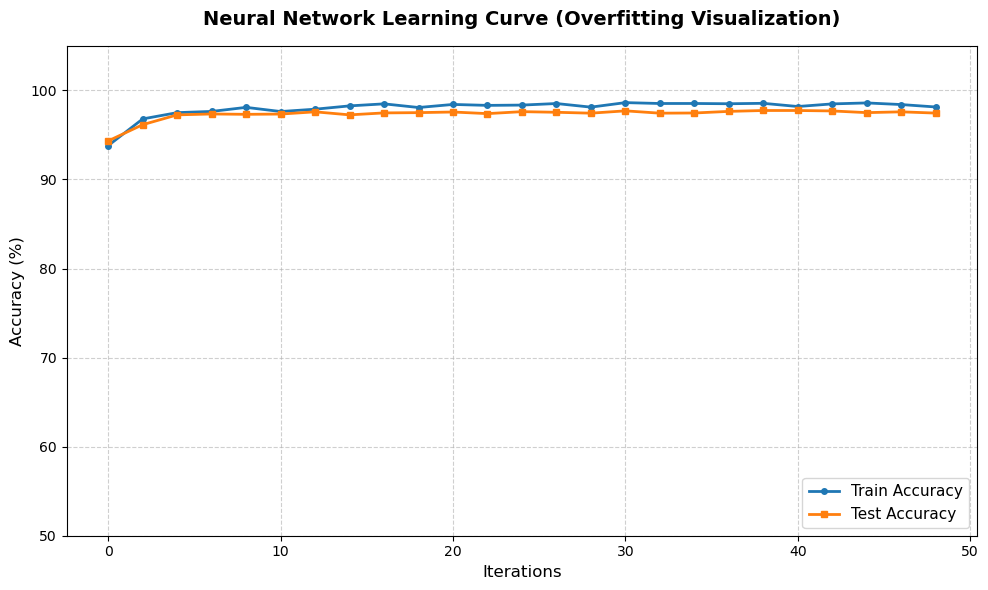

In [20]:
plt.figure(figsize=(10, 6))

# Plot Train vs Test paths
plt.plot(iters, train_accs, label='Train Accuracy', color='#1f77b4', linewidth=2, marker='o', markersize=4)
plt.plot(iters, test_accs, label='Test Accuracy', color='#ff7f0e', linewidth=2, marker='s', markersize=4)

# Formatting the chart
plt.title('Neural Network Learning Curve (Overfitting Visualization)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(50, 105) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='lower right')

# Display the plot
plt.tight_layout()
plt.show()

In [21]:
def predict(X, W, b, l):
    _, A=for_prop(X, W, b, l)
    predictions=get_predictions(A[l])
    return predictions

In [22]:
def test_prediction(X, Y, W, b):
    l = len(W) # Dynamically calculated from weight list
    predictions = predict(X, W, b, l)
    accuracy = get_accuracy(predictions, Y)
    print(f"Final Test Accuracy: {accuracy * 100:.2f}%")
    return predictions



In [23]:
print("Train Features Shape (X):", X.shape)           # (784, 2000)
print("Train Labels Shape (Y):", Y.shape)             # (2000,)
print("Test Features Shape (X_test):", X_test.shape)   # (784, 999)

Train Features Shape (X): (784, 50000)
Train Labels Shape (Y): (50000,)
Test Features Shape (X_test): (784, 10000)


In [24]:
test_preds = test_prediction(X_test, Y_test, W, b)

Final Test Accuracy: 97.67%
